**PART 0: SETUP**

In [1]:
# INSTALLING OF SCIKIT-LEARN
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#IMPORT AND VERSION
import sklearn
print(sklearn.__version__)

1.7.2


**PART 1: Data loaded, **cleaned**, and correlation heatmap shown**

In [3]:
##importation of required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline
sns.set_style('whitegrid')


Task 1: Load the dataset into a DataFrame and print its shape and column names.


In [4]:
## Loading of dataset
df = pd.read_csv("USA_Housing.csv")

print(df.shape)     #shape of the dataset

print(df.columns.tolist()) #listing the columns in the dataset



(5000, 7)
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']


Task 2:  Display the first 5 rows, then run df.info() and df.describe().

In [5]:
 ##checking the first 5 rows of the dataset
print("The first 5 rows of the dataset: ")
print(df.head())


##checking the last 5 rows of the dataset
print("The last 5 rows of the dataset: ")
print(df.tail())

The first 5 rows of the dataset: 
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\n

In [6]:
#checking the information of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
None


In [7]:
#it shows the means, standard deviations, minimum values, the quartiles and Maximum values of 6 columns in dataset
print(df.describe())


       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.991456                   1.005833   
min        17796.631190             2.644304                   3.236194   
25%        61480.562388             5.322283                   6.299250   
50%        68804.286404             5.970429                   7.002902   
75%        75783.338666             6.650808                   7.665871   
max       107701.748378             9.519088                  10.759588   

       Avg. Area Number of Bedrooms  Area Population         Price  
count                   5000.000000      5000.000000  5.000000e+03  
mean                       3.981330     36163.516039  1.232073e+06  
std                        1.234137      9925.650114  3.531176e+05  
min                        2.000000       172.61

Task 3:  Check for missing values in every column.

In [8]:
missing_values = df.isnull()
print(missing_values.sum())

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


Task 4:  Drop the Address column — it isn't useful for a numeric regression model.

In [9]:
df = df.drop('Address', axis=1)
print(df.columns.tolist())


['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']


In [14]:
## correlation of dataset
num_columns = ["Avg. Area Income", "Avg. Area House Age", "Avg. Area Number of Rooms", "Avg. Area Number of Bedrooms", "Area Population", "Price"] 
df_cor = df[num_columns].corr()
print(df_cor)

                              Avg. Area Income  Avg. Area House Age  \
Avg. Area Income                      1.000000            -0.002007   
Avg. Area House Age                  -0.002007             1.000000   
Avg. Area Number of Rooms            -0.011032            -0.009428   
Avg. Area Number of Bedrooms          0.019788             0.006149   
Area Population                      -0.016234            -0.018743   
Price                                 0.639734             0.452543   

                              Avg. Area Number of Rooms  \
Avg. Area Income                              -0.011032   
Avg. Area House Age                           -0.009428   
Avg. Area Number of Rooms                      1.000000   
Avg. Area Number of Bedrooms                   0.462695   
Area Population                                0.002040   
Price                                          0.335664   

                              Avg. Area Number of Bedrooms  Area Population  \
Avg. Area

Task 5:  Create a heatmap of the correlation between all numeric columns, including Price.

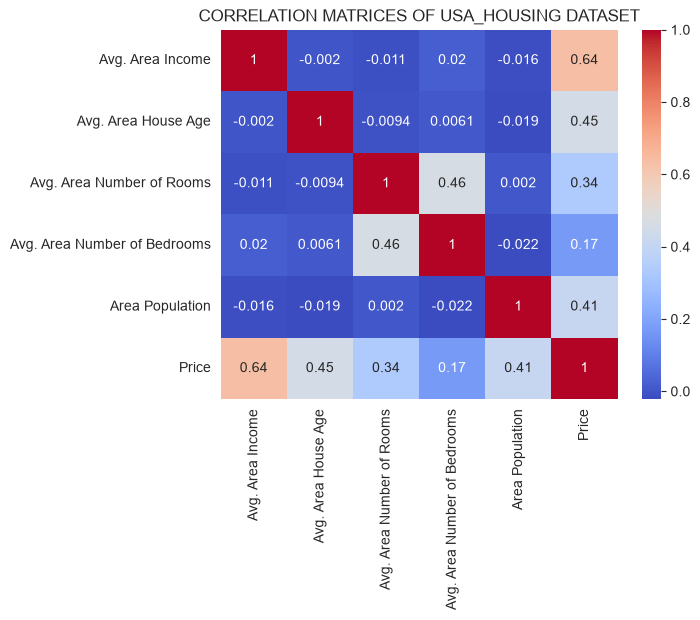

In [17]:
plt.Figure(figsize=(9, 7))
sns.heatmap(df_cor, annot = True, cmap = "coolwarm")
plt.title("CORRELATION MATRICES OF USA_HOUSING DATASET")
plt.show()

Observation Prompt — Part 1:  
1. The feature that has a the strongest correlation with price is Avg. Area Income, with correlation of 0.64
2. The weakest is Avg. Area Number of Bedrooms  with 0.17 correlation
3. With respect to price, the feature that will matter most for prediction is the one with the strongest correlation i.e, 0.64, and this is because best correlation are in range of 0.5 to 0.7


**Part 2 — Simple Linear Regression**

Task 1:  Select Avg. Area Income as X and Price as y.

In [24]:
X = df[["Avg. Area Income"]]
y =df["Price"]

Task 2:  Split the data into training and test sets (80% train, 20% test).

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

print("Train size: ", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size:  4000
Test size:  1000


Task 3:  Create and fit a LinearRegression model on the training data.

In [26]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Task 4:  Predict on the test set, then plot actual vs. predicted values as a scatter plot.

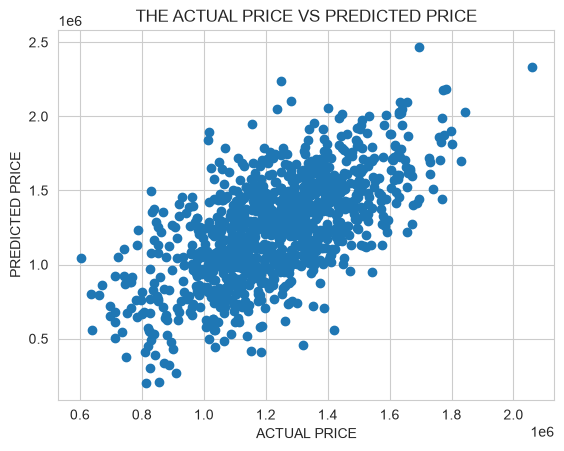

In [28]:
y_pred_simple = model_simple.predict(X_test)

plt.Figure(figsize= (8, 6))
plt.scatter(y_pred_simple, y_test)
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.title("THE ACTUAL PRICE VS PREDICTED PRICE")
plt.show()

Task 5:  Print the model's coefficient and intercept. 

In [30]:
print("Coefficient: ", model_simple.coef_[0])
print("Intercept: ", model_simple.intercept_)

Coefficient:  21.208906292657513
Intercept:  -225053.70287170145


coefficient: means that how particular feature influences the moedel predicted. From the model_simple, the coefficient is approximately 21, this means that when "Avg. Area Income" increases by 1 unit, the model expects the house price to increase by 21 units, provided that other factor remain constant

Observation Prompt — Part 2:  From the model_simple, if the average area income increase by $1, the predicted house will increase by $21.21.  Therefore, it shows that the increment in the average area income will also cause increment in house price and vice versa

**Part 3 — Multiple Linear Regression**

Task 1:  Select all numeric feature columns (everything except Price) as X, and Price as y.

In [31]:
X_multi = df.drop("Price", axis = 1)
y_multi = df["Price"]


Task 2:  Split into training and test sets (80/20), using the same random_state=42 as before.

In [55]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size= 0.2, random_state= 42)


Task 3:  Create and fit a LinearRegression model on the training data.

In [56]:
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Task 4:  Predict on the test set.

In [57]:
y_multi_pred = multi_model.predict(X_test_multi)

Task 5:  Print the coefficient for each feature next to its column name. Which feature has the largest effect on price?

In [59]:
coeff_df = pd.DataFrame(
    multi_model.coef_, X_multi.columns, columns= ["Coefficient"]
)
print(coeff_df)

                                Coefficient
Avg. Area Income                  21.578049
Avg. Area House Age           165637.026941
Avg. Area Number of Rooms     120659.948816
Avg. Area Number of Bedrooms    1651.139054
Area Population                   15.200744


The feature that has the largest effect on price is "Avg. Area House Age " with approximately 165,637 coefficient

Observation Prompt — Part 3:  
--"Avg. Area House Age" feature's coefficient is largest
--No, is not the most important
--Because the features has differnt scales


**Part 4 — Evaluating & Comparing Both Models**

Task 1:  Calculate MAE, MSE, RMSE, and R² for the simple regression model (Part 2).

In [60]:
mae_simple = metrics.mean_absolute_error(y_test, y_pred_simple)
mse_simple = metrics.mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = metrics.r2_score(y_test, y_pred_simple)
 
print('MAE:', mae_simple)
print('MSE:', mse_simple)
print('RMSE:', rmse_simple)
print('R2:', r2_simple)


MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2: 0.39694865192619766


Task 2:  Calculate the same four metrics for the multiple regression model (Part 3)

In [61]:
mae_multi = metrics.mean_absolute_error(y_test_multi, y_multi_pred)
mse_multi = metrics.mean_squared_error(y_test_multi, y_multi_pred)
rmse_multi = np.sqrt(mse_multi)
r2_multi = metrics.r2_score(y_test, y_multi_pred)

print("MAE: ", mae_multi)
print("MSE: ", mse_multi)
print("RMSE: ", rmse_multi)
print("R2: ", r2_multi)

MAE:  80749.70133754353
MSE:  10060877695.58801
RMSE:  100303.92662098534
R2:  0.9182258225916143


Task 3:  Build a small comparison table (as a DataFrame) showing both models' metrics side by side.

In [71]:
comparison = pd.DataFrame({
    'Simple (Income only)': [mae_simple, mse_simple, rmse_simple, r2_simple],
    'Multiple (All features)': [mae_multi, mse_multi, rmse_multi, r2_multi]
}, index=['MAE', 'MSE', 'RMSE', 'R2'])
print(comparison)


      Simple (Income only)  Multiple (All features)
MAE           2.168264e+05             8.074970e+04
MSE           7.419489e+10             1.006088e+10
RMSE          2.723874e+05             1.003039e+05
R2            3.969487e-01             9.182258e-01


Task 4:  Plot a histogram of the residuals (y_test − predictions) for the multiple regression model. Check whether they look roughly normally distributed.

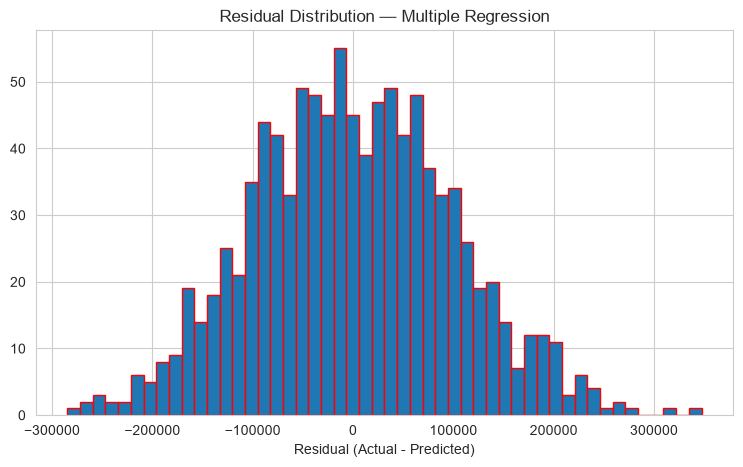

In [93]:
residuals = y_test_multi - y_multi_pred

plt.figure(figsize=(9, 5))
plt.hist( residuals, bins = 50, edgecolor = "red" )
plt.title('Residual Distribution — Multiple Regression')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()


Observation Prompt — Part 4:   THe model that perform more better is Multiple Regression Model, because has less errors than the SImple Reggression Model. Yes, from the output of the models, more features can give better performance. From the the shape of the graphy, it shows that errors are very small because most of the  features falls on residual zero (0) which is the highest in the histogram

**Part 5 — Bonus: Polynomial Regression**

Task 1:  Using only Avg. Area Income, create degree-2 polynomial features.

In [98]:
from sklearn.preprocessing import PolynomialFeatures
 
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)



Task 2:  Split, fit a LinearRegression model on the polynomial features, and calculate its R² score.

In [102]:

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)


poly_model = LinearRegression() #fitting of linear regression into poly regression
poly_model.fit(X_poly_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [108]:
#calculation of R2
y_poly_pred = poly_model.predict(X_poly_test)
r2_poly = metrics.r2_score(y_poly_pred, y_test)
print("R2_poly: ", r2_poly)

R2_poly:  0.9111534910163963


Task 3:  Compare this R² score to the simple linear regression R² from Part 2. Did the curve improve the fit?

In [110]:
comparison = pd.DataFrame({
    "simple_model r2" : [r2_simple],
    "poly_model r2" : [r2_poly ]
})
print(comparison)

   simple_model r2  poly_model r2
0         0.396949       0.911153


In [111]:
improve_R2_value = r2_poly - r2_simple
print(" The r2 improved by: ", improve_R2_value)

 The r2 improved by:  0.5142048390901987


Observation Prompt — Bonus:  Yes the curve improved. from the result the r2 improved by 0.51 approximately.